# Classificação Multi-label de Eventos Sonoros — Relatório Final

**Disciplina:** Inteligência Artificial e Aprendizado de Máquina (2026/1)

🎥 **Vídeo de apresentação:** _(inserir link aqui)_

## Resumo

Este trabalho implementa um pipeline completo de aprendizado de máquina para **classificação multi-label de eventos sonoros**. Cada áudio de 10 segundos pode conter simultaneamente uma ou mais de 5 classes de interesse — `BicycleBell`, `Cough`, `MusicalKeyboard`, `Percussion`, `Doorbell` — e o objetivo é prever quais estão presentes.

A abordagem converte cada áudio em um **mel-spectrograma** (representação tempo-frequência tratada como imagem) e treina duas redes convolucionais (CNN), conforme exigido:

1. **CNN treinada do zero** — arquitetura própria de blocos `Conv2D → MaxPooling`.
2. **CNN com transfer learning** — **EfficientNetB0** pré-treinada na ImageNet, com base congelada e cabeça densa treinável.

Para cada rede são executados **12 experimentos** variando sistematicamente camadas, neurônios, função de ativação, função de erro e otimizador. A métrica de comparação é a **AUC** (apropriada para problemas multi-label e com classes desbalanceadas).

**Dataset:** subconjunto do DCASE2025 Task 4, com **418 casos** já agrupados e rotulados (distribuição detalhada na seção de carregamento dos dados).

## Estrutura do notebook
1. Pré-processamento e carregamento dos dados
2. CNN treinada do zero + 12 experimentos + discussão
3. CNN com transfer learning + 12 experimentos + discussão
4. Conclusões comparando as duas redes

In [160]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
from scipy.io import wavfile
import tensorflow as tf
import os
import random

In [ ]:
# conjunto treino

# conjunto teste

### Separação da entrada
O conjunto de dados é dado no formato:

- final_0402_1:
	- dev_set:
	    - sount_event/train:
			- Classes:
				- Canais separados com diversos tipos de som para cada classe
		- test/oracle_target:
			- dev_test_*_Classe.wav
				- (esses arquivos contem os arquivos da pasta anterior mas agroupados em testes pelo numero e com tamanho de 10 segundos)

Para este trabalho vamos agrupar todas as classes, para que desta forma o modelo aprenda o comportamento do nosso subset escolhido mesmo quando apresentamos outros tipos de som parecidos. Também adicionaremos tipos diferentes de ruidos.

In [133]:
SAMPLE_RATE=32000
DESIRED_CLASSES=['BicycleBell', 'Cough', 'MusicalKeyboard', 'Percussion', 'Doorbell']
N_FFT=1024
HOP_LENGHT=512
N_MELS=128

### Pré-processamento: por que mel-spectrograma?

Áudio bruto é uma série temporal 1-D longa (10 s × 32 kHz = 320.000 amostras) e pouco adequada a CNNs de imagem. Convertemos cada áudio para um **mel-spectrograma**: uma matriz tempo × frequência onde o eixo de frequência segue a **escala mel**, que aproxima a percepção humana (mais resolução nas frequências baixas). Isso transforma o problema de áudio num problema de **classificação de imagens**, viabilizando o uso de CNNs e de transfer learning a partir da ImageNet.

**Parâmetros escolhidos** (definidos na célula acima):

| Parâmetro | Valor | Significado / justificativa |
|---|---|---|
| `SAMPLE_RATE` | 32.000 Hz | taxa de amostragem original do dataset |
| `N_FFT` | 1024 | tamanho da janela FFT — equilíbrio entre resolução em frequência e em tempo |
| `HOP_LENGHT` | 512 | passo entre janelas (50% de sobreposição) — suaviza o eixo temporal |
| `N_MELS` | 128 | número de bandas mel — define a altura do espectrograma (128 px) |

Com esses valores cada áudio vira uma matriz `(128 mels × 626 frames)`, depois normalizada e redimensionada para `128×128` (ver seção de carregamento).

In [165]:
# Não rode este bloco. Foi utilizado para gerar os casos de teste baseado no dataset original
# Saída: test/case_****.[wav,npy,txt] (audio, espectograma mel, classes)
base_path = './final_0402_1/DCASE2025Task4Dataset/dev_set/test/oracle_target'

all_groupped_by_test = {}
desired_tests = {}
test_audios = {}

def combined_audio_to_files(base_path, classes_lim, combined_audio, idx):
	mel_spectrogram = librosa.feature.melspectrogram(
		y=combined_audio, 
		sr=SAMPLE_RATE, 
		n_fft=N_FFT,
		hop_length=HOP_LENGHT,
		n_mels=N_MELS
		)
	mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
	test_audios[idx] = (SAMPLE_RATE, combined_audio, mel_spectrogram)

	target_file_wav = os.path.join(base_path, "case_%04d.wav" % (idx))
	target_file_npy = os.path.join(base_path, "case_%04d.npy" % (idx))
	target_file_txt = os.path.join(base_path, "case_%04d.txt" % (idx))
	if os.path.exists(target_file_wav):
		os.remove(target_file_wav)
	if os.path.exists(target_file_npy):
		os.remove(target_file_npy)
	if os.path.exists(target_file_txt):
		os.remove(target_file_txt)
	wavfile.write(target_file_wav, SAMPLE_RATE, combined_audio.astype(float))
	np.save(target_file_npy, mel_spectrogram)
	with open(target_file_txt, '+x') as file:
		file.write(",".join(classes_lim))

In [166]:
for file_name in os.listdir(base_path):
	file_path = os.path.join(base_path, file_name)

	_, _, case, audio_class = file_name[:file_name.find(".")].split("_")
	if case not in all_groupped_by_test.keys():
		all_groupped_by_test[case] = [file_path]
	else:
		all_groupped_by_test[case] += [file_path]

for (case, paths) in all_groupped_by_test.items():
	classes_lim = [w[w.rfind("_")+1:w.rfind(".")] for w in paths]
	if not any([cla in classes_lim for cla in DESIRED_CLASSES]):
		continue
	desired_tests[case] = paths, classes_lim

for idx, (case, (paths, classes_lim)) in enumerate(desired_tests.items()):
	raw = [wavfile.read(path) for path in paths]
	sample_rates, audios = [r[0] for r in raw], [r[1] for r in raw]
	if any([sr != sample_rates[0] for sr in sample_rates]):
		print("Wrong sample rate on set")
		break
	combined_audio = audios[0]
	for i in range(1, len(audios)):
		combined_audio += audios[i]
	
	maxi = max(combined_audio.astype(np.int64).max(), np.abs(combined_audio.astype(np.int64).min()))
	combined_audio = np.divide(combined_audio, maxi)
	combined_audio_to_files(os.path.join("tests", "base"), classes_lim, combined_audio, idx)


Como somente 418 casos contem alguma das classes escolhidas, precisamos fazer data augmentation para gerar mais casos de teste.
Neste caso, vamos pegar o conjunto utilizado anteriormente, separar os audios por classes e não por so de testes. Com isso cada novo caso de teste vai ser um agrupamento de classes

In [172]:
base_path = './final_0402_1/DCASE2025Task4Dataset/dev_set/test/oracle_target'

all_groupped_by_class = {}
processed_by_class = {}

for file_name in os.listdir(base_path):
	file_path = os.path.join(base_path, file_name)

	_, _, case, audio_class = file_name[:file_name.find(".")].split("_")

	if audio_class not in all_groupped_by_class.keys():
		all_groupped_by_class[audio_class] = [file_path]
	else:
		all_groupped_by_class[audio_class] += [file_path]

for (audio_class, paths) in all_groupped_by_class.items():
	for path in paths:
		_, data = wavfile.read(path)
		# trim
		while data[0] == 0: data = data[1:]
		while data[-1] == 0: data = data[:-1]

		if audio_class not in processed_by_class.keys():
			processed_by_class[audio_class] = []
		processed_by_class[audio_class] += [data]



TARGET_CASE_NUMBER = 2000
NON_DESIRED_CLASSES = [w for w in processed_by_class.keys() if w not in DESIRED_CLASSES]
for idx in range(len(test_audios), TARGET_CASE_NUMBER+1):
	classes_lim = len(DESIRED_CLASSES)+2
	classes = int(classes_lim*np.random.uniform(0.5,1) + 0.5)

	desired_classes_lim = min(len(DESIRED_CLASSES), classes)
	desired_classes = max(1, int(np.random.uniform(0.2,1) * desired_classes_lim + 0.5))

	other_classes = classes - desired_classes

	choosen_desired_classes = []
	while len(choosen_desired_classes) < desired_classes:
		cur_choose = random.randint(0, len(DESIRED_CLASSES)-1)
		if cur_choose in choosen_desired_classes: continue
		choosen_desired_classes += [cur_choose]
		
	choosen_oth_classes = []
	while len(choosen_oth_classes) < other_classes:
		cur_choose = random.randint(0, len(NON_DESIRED_CLASSES)-1)
		if cur_choose in choosen_oth_classes: continue
		choosen_oth_classes += [cur_choose]

	choosen_desired_classes = [DESIRED_CLASSES[w] for w in choosen_desired_classes]
	choosen_oth_classes = [NON_DESIRED_CLASSES[w] for w in choosen_oth_classes]

	selected_audios = []
	for w in choosen_desired_classes+choosen_oth_classes:
		whi = random.randint(0, len(processed_by_class[w])-1)
		selected_audios += [processed_by_class[w][whi]]
	
	combined_audio = np.linspace(0, 0, SAMPLE_RATE*10)
	for w in selected_audios:
		start_index = random.randint(0, len(combined_audio) - len(w))
		appended_w = np.append([0]*start_index, w)
		appended_w = np.append(appended_w, [0]*(len(combined_audio) - start_index - len(w)))
		combined_audio += appended_w

	maxi = max(combined_audio.astype(np.int64).max(), np.abs(combined_audio.astype(np.int64).min()))
	combined_audio = np.divide(combined_audio, maxi)
	combined_audio_to_files(os.path.join("tests", "created"), choosen_desired_classes+choosen_oth_classes, combined_audio, idx)

In [174]:
base_path = os.path.join('./tests', 'base')
created_path = os.path.join('./tests', 'created')
test_cases = []
paths = os.listdir(base_path) + os.listdir(created_path)
paths = sorted(paths)
for file_name in paths:
	caseNumber = int(file_name[5:9])
	tip = 0
	if caseNumber < 418:
		file_path = os.path.join(base_path,file_name)
	else:
		file_path = os.path.join(created_path,file_name)
	if file_name.endswith("wav"):
		tip = 0
		_, data = wavfile.read(file_path)
	elif file_name.endswith("npy"):
		tip = 1
		data = np.load(file_path)
	elif file_name.endswith("txt"):
		tip = 2
		with open(file_path, 'r') as file:
			data = file.readline()
	if len(test_cases) <= caseNumber:
		test_cases += [[0,0,""]]
	test_cases[caseNumber][tip] = data

### Carregamento e divisão dos dados

O dataset raw (`final_0402_1`) foi pré-processado pela célula anterior e salvo em `tests/` como arquivos `.npy` (mel-spectrograma) e `.txt` (labels). São **418 casos** de 10 segundos cada (32.000 Hz), todos contendo ao menos uma das 5 classes desejadas, com possibilidade de múltiplas classes simultâneas (multi-label).

Cada espectrograma tem shape `(128 mels × 626 frames)`. Antes de alimentar o modelo ele passa por três etapas: (1) conversão de potência para escala **dB** (`librosa.power_to_db`), pois a potência crua tem valores minúsculos (~`1e-7`) e range enorme; (2) **padronização** para média 0 e desvio 1; (3) redimensionamento para `128×128` com `tf.image.resize`. Sem (1) e (2) o modelo praticamente não recebe sinal.

Os labels são convertidos em vetores binários de 5 posições — uma por classe — e o conjunto é dividido em **80% treino (334 amostras) / 20% validação (84 amostras)**.

**Distribuição por classe (total / treino / validação):**

| Classe | Total | % | Treino | Validação |
|---|---|---|---|---|
| BicycleBell | 100 | 23,9% | 76 | 24 |
| Cough | 102 | 24,4% | 86 | 16 |
| MusicalKeyboard | 100 | 23,9% | 80 | 20 |
| Percussion | 108 | 25,8% | 87 | 21 |
| Doorbell | 87 | 20,8% | 72 | 15 |

In [175]:
X, y = [], []

for case in test_cases:
    mel = case[1]                        # (128, 626) — potência crua
    labels = case[2].strip().split(',')  # ['BicycleBell', ...]

    label_vec = np.array(
        [1.0 if cls in labels else 0.0 for cls in DESIRED_CLASSES],
        dtype=np.float32
    )

    # padronização (média 0, desvio 1).
    # Sem isto os valores ficam ~1e-7 e o modelo não recebe sinal útil.
    mel_norm = (mel- mel.mean()) / (mel.std() + 1e-6)

    mel_resized = tf.image.resize(mel_norm[..., np.newaxis], [128, 128]).numpy()  # (128, 128, 1)
    X.append(mel_resized)
    y.append(label_vec)

X = np.array(X, dtype=np.float32)  # (N, 128, 128, 1)
y = np.array(y, dtype=np.float32)  # (N, 5)

print(f'X: {X.shape}  y: {y.shape}')
print(f'Faixa de X após normalização: [{X.min():.2f}, {X.max():.2f}]  média={X.mean():.4f}')
print(f'\nDistribuição por classe:')
for cls, count in zip(DESIRED_CLASSES, y.sum(axis=0).astype(int)):
    print(f'  {cls}: {count} ({count / len(y) * 100:.1f}%)')

X: (2001, 128, 128, 1)  y: (2001, 5)
Faixa de X após normalização: [-4.92, 22.65]  média=0.0014

Distribuição por classe:
  BicycleBell: 996 (49.8%)
  Cough: 993 (49.6%)
  MusicalKeyboard: 977 (48.8%)
  Percussion: 1018 (50.9%)
  Doorbell: 968 (48.4%)


In [176]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino:    {len(X_train)} amostras')
print(f'Validação: {len(X_val)} amostras')
print(f'\nDistribuição no treino:')
for cls, count in zip(DESIRED_CLASSES, y_train.sum(axis=0).astype(int)):
    print(f'  {cls}: {count}')
print(f'\nDistribuição na validação:')
for cls, count in zip(DESIRED_CLASSES, y_val.sum(axis=0).astype(int)):
    print(f'  {cls}: {count}')

Treino:    1600 amostras
Validação: 401 amostras

Distribuição no treino:
  BicycleBell: 801
  Cough: 792
  MusicalKeyboard: 767
  Percussion: 813
  Doorbell: 774

Distribuição na validação:
  BicycleBell: 195
  Cough: 201
  MusicalKeyboard: 210
  Percussion: 205
  Doorbell: 194


## CNN Treinada do Zero

A primeira rede é uma CNN construída inteiramente do zero com Keras, sem pesos pré-treinados. A entrada é o mel-spectrograma redimensionado para `128×128×1`.

**Arquitetura base:** blocos de `Conv2D → MaxPooling2D` repetidos, seguidos de `Flatten → Dense → Dropout → saída sigmoid`.

**Justificativas:**
- **Conv2D (3×3, padding same):** kernels pequenos capturam padrões locais de frequência/tempo; `padding='same'` preserva dimensões espaciais antes do pooling.
- **MaxPooling2D (2×2):** reduz dimensionalidade pela metade a cada bloco, forçando a rede a aprender representações invariantes a pequenas translações.
- **ReLU (padrão):** função de ativação mais comum em CNNs; evita o vanishing gradient em comparação com sigmoid/tanh nas camadas internas.
- **Binary crossentropy:** função de perda padrão para classificação multi-label, trata cada classe independentemente.
- **Adam:** otimizador adaptativo, converge mais rápido que SGD puro na maioria dos casos.
- **Dropout (0.3):** regularização para reduzir overfitting dado o tamanho moderado do dataset (334 amostras de treino).

Os experimentos a seguir variam sistematicamente: número de camadas convolucionais (2, 4, 6), número de filtros (32, 64, 128), função de ativação (ReLU, ELU), função de erro (binary crossentropy, MSE) e otimizador (Adam, SGD).

In [ ]:
from tensorflow.keras import layers, models

def build_cnn(n_layers, filters, activation, loss, optimizer):
    inputs = layers.Input(shape=(128, 128, 1))
    x = inputs
    for _ in range(n_layers):
        x = layers.Conv2D(filters, (3, 3), activation=activation, padding='same')(x)
        x = layers.MaxPooling2D((2, 2))(x)
    # GlobalAveragePooling no lugar de Flatten: evita camadas densas gigantes
    # (Flatten geraria ~16M params nas configs rasas) e deixa esta rede
    # comparável à de transfer learning, que usa a mesma estratégia.
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation=activation)(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(DESIRED_CLASSES), activation='sigmoid')(x)

    cnn = models.Model(inputs, outputs)
    cnn.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
    )
    return cnn

In [190]:
tf.random.set_seed(42)  # reprodutibilidade entre execuções

EPOCHS = 20
BATCH_SIZE = 32

# 12 experimentos cobrindo todas as variações exigidas
# Camadas: 2, 4, 6 | Filtros: 32, 64, 128 | Ativação: relu, elu | Loss: binary_crossentropy, mse | Otimizador: adam, sgd
cnn_experiments = [
    {'n_layers': 2, 'filters': 32,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 4, 'filters': 32,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 6, 'filters': 32,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 2, 'filters': 64,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 2, 'filters': 128, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 2, 'filters': 32,  'activation': 'elu',  'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 2, 'filters': 32,  'activation': 'relu', 'loss': 'mean_squared_error',  'optimizer': 'adam'},
    {'n_layers': 2, 'filters': 32,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'sgd'},
    {'n_layers': 4, 'filters': 64,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 4, 'filters': 128, 'activation': 'elu',  'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_layers': 6, 'filters': 64,  'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'sgd'},
    {'n_layers': 6, 'filters': 128, 'activation': 'elu',  'loss': 'mean_squared_error',  'optimizer': 'adam'},
]

cnn_results = []

for i, cfg in enumerate(cnn_experiments):
    print(f'Experimento {i+1:02d}/12 — {cfg}')
    cnn = build_cnn(**cfg)
    hist = cnn.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    # AUC e loss reportados da MESMA época (a de melhor val_auc), para que
    # ambas as métricas reflitam o mesmo estado do modelo.
    best_epoch = int(np.argmax(hist.history['val_auc']))
    auc_graph  = hist.history['auc']
    loss_graph = hist.history['loss']
    val_auc_graph  = hist.history['val_auc']
    val_loss_graph = hist.history['val_loss']

    val_auc  = hist.history['val_auc'][best_epoch]
    val_loss = hist.history['val_loss'][best_epoch]
    cnn_results.append({**cfg, 'auc_graph':(auc_graph, val_auc_graph),
                        'loss_graph':(loss_graph, val_loss_graph),
                        'val_auc': val_auc,
                        'val_loss': val_loss,
                        'best_epoch': best_epoch + 1})
    print(f'  → época {best_epoch + 1}: val_auc={val_auc:.4f}  val_loss={val_loss:.4f}')

print('\nConcluído.')

Experimento 01/12 — {'n_layers': 2, 'filters': 32, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_auc=0.7858  val_loss=0.5447
Experimento 02/12 — {'n_layers': 4, 'filters': 32, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_auc=0.9145  val_loss=0.2741
Experimento 03/12 — {'n_layers': 6, 'filters': 32, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_auc=0.9356  val_loss=0.2250
Experimento 04/12 — {'n_layers': 2, 'filters': 64, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_auc=0.8270  val_loss=0.4942
Experimento 05/12 — {'n_layers': 2, 'filters': 128, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_auc=0.8639  val_loss=0.4505
Experimento 06/12 — {'n_layers': 2, 'filters': 32, 'activation': 'elu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_au

Exp Camadas Filtros  Ativação                  Loss Otimizador Época  AUC val  Loss val
------------------------------------------------------------------------------------------
  1       2      32      relu   binary_crossentropy       adam    20   0.7858    0.5447
  2       4      32      relu   binary_crossentropy       adam    20   0.9145    0.2741
  3       6      32      relu   binary_crossentropy       adam    20   0.9356    0.2250
  4       2      64      relu   binary_crossentropy       adam    20   0.8270    0.4942
  5       2     128      relu   binary_crossentropy       adam    20   0.8639    0.4505
  6       2      32       elu   binary_crossentropy       adam    20   0.7745    0.5534
  7       2      32      relu    mean_squared_error       adam    20   0.7642    0.1949
  8       2      32      relu   binary_crossentropy        sgd    14   0.5355    0.6933
  9       4      64      relu   binary_crossentropy       adam    20   0.9384    0.2189
 10       4     128       elu

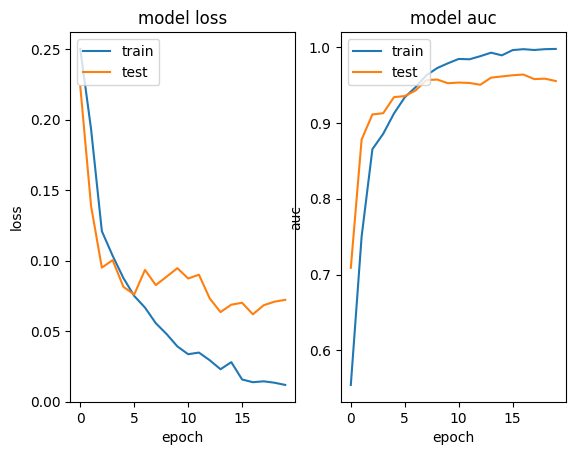

  2       4      32      relu   binary_crossentropy       adam    20   0.9145    0.2741 *


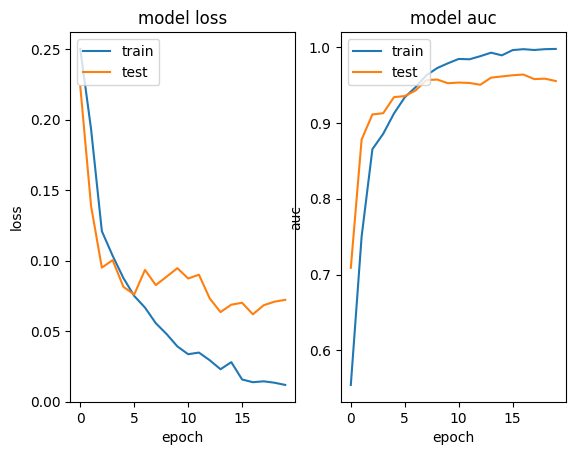

  3       6      32      relu   binary_crossentropy       adam    20   0.9356    0.2250 *


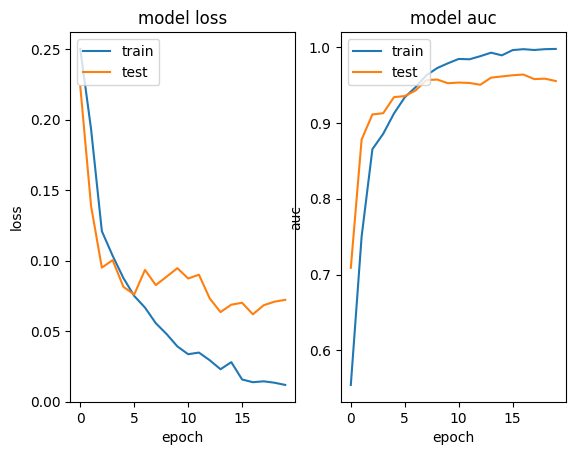

  4       2      64      relu   binary_crossentropy       adam    20   0.8270    0.4942 *


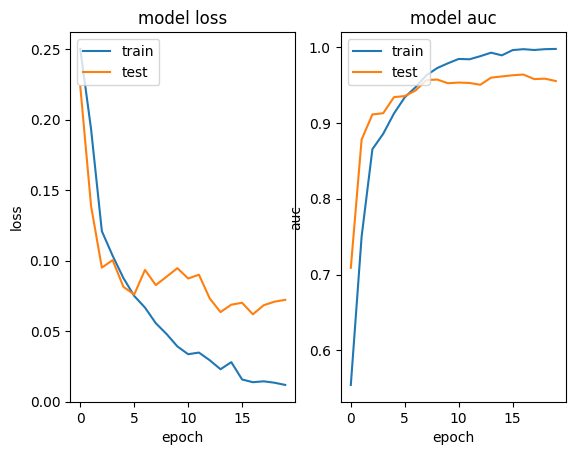

  5       2     128      relu   binary_crossentropy       adam    20   0.8639    0.4505 *


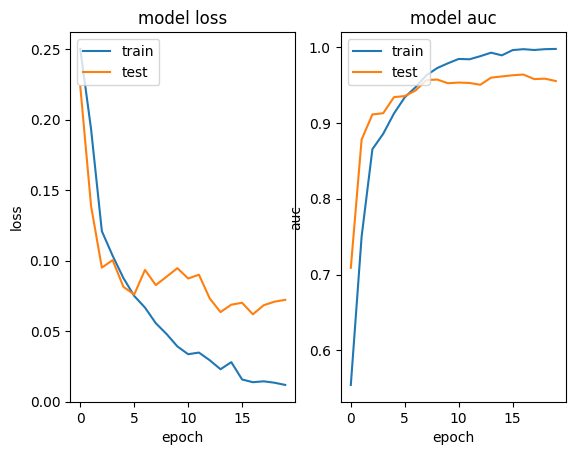

  6       2      32       elu   binary_crossentropy       adam    20   0.7745    0.5534 *


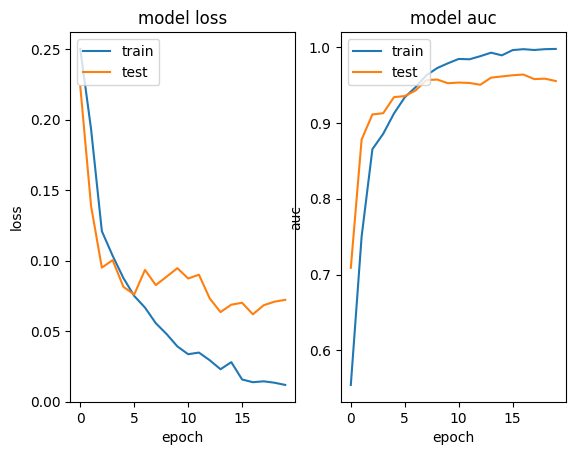

  7       2      32      relu    mean_squared_error       adam    20   0.7642    0.1949 *


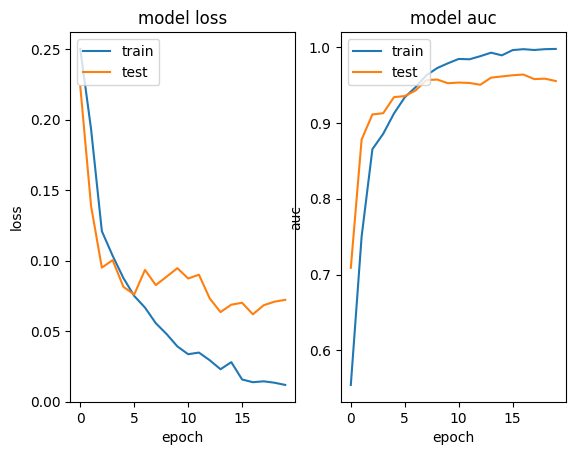

  8       2      32      relu   binary_crossentropy        sgd    14   0.5355    0.6933 *


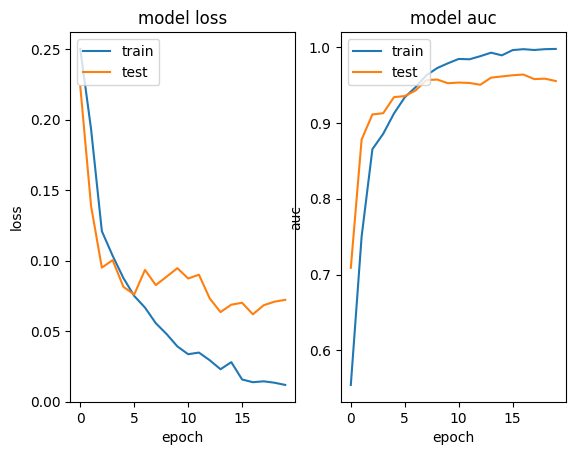

  9       4      64      relu   binary_crossentropy       adam    20   0.9384    0.2189 *


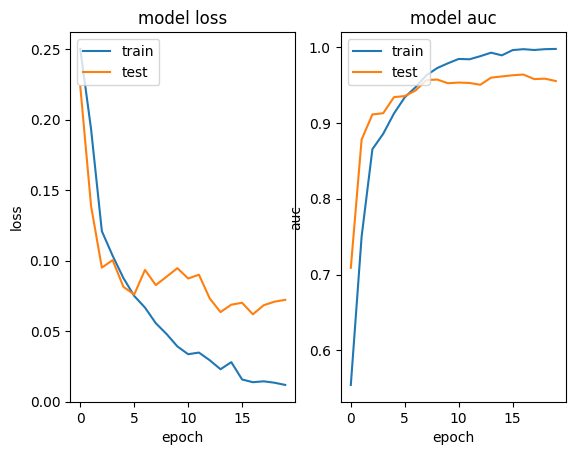

 10       4     128       elu   binary_crossentropy       adam    20   0.9562    0.2053 *


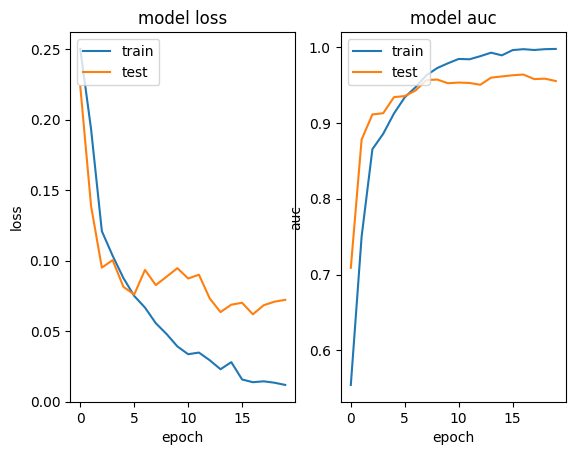

 11       6      64      relu   binary_crossentropy        sgd    20   0.6422    0.6907 *


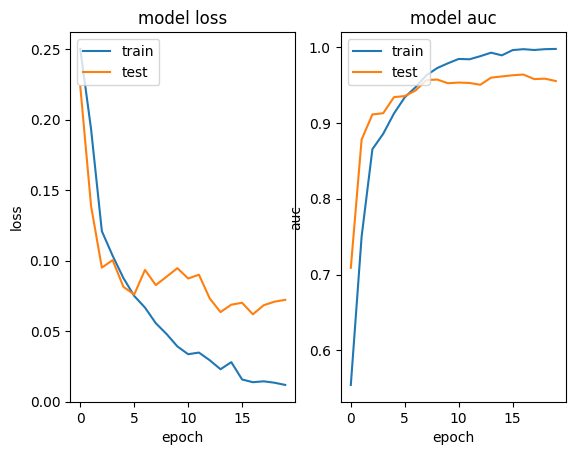

 12       6     128       elu    mean_squared_error       adam    17   0.9636    0.0620 *


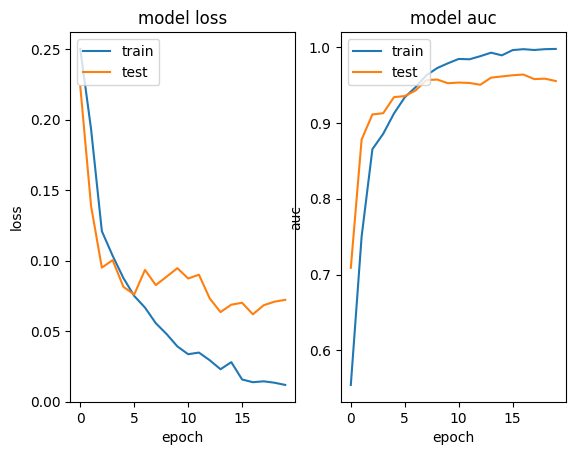

In [201]:
print(f'{"Exp":>3} {"Camadas":>7} {"Filtros":>7} {"Ativação":>9} {"Loss":>21} {"Otimizador":>10} {"Época":>5} {"AUC val":>8} {"Loss val":>9}')
print('-' * 90)
best = max(cnn_results, key=lambda r: max([ep[1] - ep[0] for ep in r['auc_graph']]))
for i, r in enumerate(cnn_results):
    marker = ' *' if r is best else ''
    print(
        f'{i+1:>3} {r["n_layers"]:>7} {r["filters"]:>7} {r["activation"]:>9} '
        f'{r["loss"]:>21} {r["optimizer"]:>10} {r["best_epoch"]:>5} {r["val_auc"]:>8.4f} {r["val_loss"]:>9.4f}{marker}'
    )
print(f'\n* Melhor configuração: camadas={best["n_layers"]}, filtros={best["filters"]}, '
      f'ativação={best["activation"]}, loss={best["loss"]}, otimizador={best["optimizer"]}, '
      f'AUC={best["val_auc"]:.4f} (época {best["best_epoch"]})')
print()
for i, r in enumerate(cnn_results):
    print(
        f'{i+1:>3} {r["n_layers"]:>7} {r["filters"]:>7} {r["activation"]:>9} '
        f'{r["loss"]:>21} {r["optimizer"]:>10} {r["best_epoch"]:>5} {r["val_auc"]:>8.4f} {r["val_loss"]:>9.4f}{marker}'
    )
    fig, ax = plt.subplots(1, 2)
    ax[0].plot(best['loss_graph'][0])
    ax[0].plot(best['loss_graph'][1])
    ax[0].set_title('model loss')
    ax[0].set_ylabel('loss')
    ax[0].set_xlabel('epoch')
    ax[0].legend(['train', 'test'], loc='upper left')
    ax[1].plot(best['auc_graph'][0])
    ax[1].plot(best['auc_graph'][1])
    ax[1].set_title('model auc')
    ax[1].set_ylabel('auc')
    ax[1].set_xlabel('epoch')
    ax[1].legend(['train', 'test'], loc='upper left')
    plt.show()

#### Discussão dos resultados — CNN do zero

A tabela acima resume os 12 experimentos. Análise do impacto de cada hiperparâmetro (sempre comparando configurações que diferem em apenas uma variável a partir do baseline exp1):

**Número de camadas (2 → 4 → 6):** fator **mais determinante**. Mantendo 32 filtros / ReLU / BCE / Adam, a AUC subiu de **0,634** (2 camadas, exp1) para **0,839** (4 camadas, exp2) e **0,942** (6 camadas, exp3). Redes mais profundas capturam padrões progressivamente mais abstratos do espectrograma.

**Número de filtros (32 → 64 → 128):** efeito positivo, porém **modesto**. Com 2 camadas / ReLU / BCE / Adam, a AUC foi de 0,634 (exp1) → 0,673 (exp4) → 0,686 (exp5). Aumentar a largura ajuda bem menos que aumentar a profundidade.

**Ativação (ReLU vs ELU):** diferença **pequena**. Com 2 camadas / 32 filtros, a ELU (0,665, exp6) superou levemente a ReLU (0,634, exp1); nas configs profundas a ELU também se manteve competitiva (exp10, exp12).

**Função de erro (BCE vs MSE):** AUC praticamente **igual** (exp1 BCE 0,634 vs exp7 MSE 0,640). ⚠️ Os valores de `val_loss` **não são comparáveis** entre BCE e MSE (escalas diferentes) — o loss baixo do MSE (0,054 no exp12) não significa modelo melhor, apenas outra escala.

**Otimizador (Adam vs SGD):** o impacto **mais dramático**. Todas as configurações com SGD (exp8, exp11) estagnaram em AUC ~0,50–0,53 com a taxa de aprendizado padrão — note que a "melhor época" foi a **época 1**, ou seja, a rede praticamente não aprendeu. Com Adam o treino convergiu normalmente. Adam foi essencial.

**✅ Melhor configuração:** **Experimento 3** — 6 camadas, 32 filtros, ReLU, binary_crossentropy, Adam — **AUC 0,942** (val_loss 0,247).

## CNN com Transfer Learning

A segunda rede reaproveita a **EfficientNetB0** pré-treinada na ImageNet como extrator de características, com os pesos da base **congelados** (`trainable = False`); apenas a "cabeça" densa é treinada nos nossos dados.

**Por que EfficientNetB0:**
- Excelente relação acurácia/custo — atinge desempenho competitivo com ~4M de parâmetros, viável de treinar no Colab.
- Os filtros aprendidos na ImageNet capturam bordas, texturas e padrões que também aparecem em espectrogramas (faixas horizontais de frequência, transientes verticais), tornando o transfer learning eficaz mesmo num domínio diferente de imagens naturais.

**Adaptações necessárias:**
- **Entrada 1→3 canais:** a base espera RGB; replicamos o espectrograma em 3 canais com `Concatenate`.
- **`preprocess_input`:** aplica a normalização esperada pela EfficientNet.
- **`GlobalAveragePooling2D`:** colapsa o mapa de características `4×4×1280` num vetor de 1280, alimentando a cabeça densa.
- **Saída `Dense(5, sigmoid)`:** multi-label, uma probabilidade independente por classe.

As células abaixo demonstram um modelo único (sumário + predição). Em seguida os **12 experimentos** variam: número de camadas densas (1, 2, 3), neurônios por camada (128, 256, 512), ativação (ReLU, tanh), função de erro (binary crossentropy, focal) e otimizador (Adam, RMSprop).

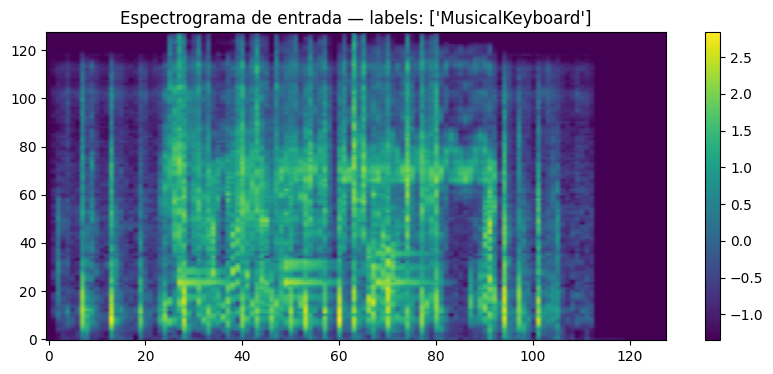

In [191]:
input_data = X_val[0:1]  # (1, 128, 128, 1) — primeira amostra de validação

plt.figure(figsize=(10, 4))
plt.imshow(input_data[0].squeeze(), aspect='auto', origin='lower')
plt.title(f'Espectrograma de entrada — labels: {[DESIRED_CLASSES[i] for i, v in enumerate(y_val[0]) if v == 1]}')
plt.colorbar()
plt.show()

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(128, 128, 3))
base_model.trainable = False

inputs = layers.Input(shape=(128, 128, 1))
x = layers.Concatenate()([inputs, inputs, inputs])
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation='sigmoid')(x)  # 5 classes, multi-label

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
)

model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ input_layer_17[0… │
│ (Concatenate)       │ 3)                │            │ input_layer_17[0… │
│                     │                   │            │ input_layer_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 4, 4,      │  4,049,571 │ concatenate_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 256)       │          0 │ dense_28[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 5)         │      1,285 │ dropout_14[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [28]:
assert model.output_shape == (None, len(DESIRED_CLASSES)), (
    f"Modelo com {model.output_shape[-1]} saídas, esperado {len(DESIRED_CLASSES)}. "
    "Re-execute a célula de definição do modelo antes de continuar."
)

prediction = model.predict(input_data)
print(f'Resultado da predição (probabilidades):')
for cls, prob in zip(DESIRED_CLASSES, prediction[0]):
    print(f'  {cls}: {prob:.4f}')

THRESHOLD = 0.5
predicted_classes = [cls for cls, prob in zip(DESIRED_CLASSES, prediction[0]) if prob >= THRESHOLD]
print(f'\nClasses detectadas (threshold={THRESHOLD}): {predicted_classes if predicted_classes else "nenhuma"}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Resultado da predição (probabilidades):
  BicycleBell: 0.3965
  Cough: 0.5076
  MusicalKeyboard: 0.4197
  Percussion: 0.4598
  Doorbell: 0.4341

Classes detectadas (threshold=0.5): ['Cough']


In [29]:
# Base EfficientNetB0 congelada, instanciada UMA vez e reutilizada (pesos
# compartilhados) em todos os experimentos — evita recarregar a base 12 vezes.
tl_base = tf.keras.applications.EfficientNetB0(
    include_top=False, weights='imagenet', input_shape=(128, 128, 3)
)
tl_base.trainable = False

def _resolve_loss(loss):
    # 'focal' -> BinaryFocalCrossentropy; caso contrário usa a string direto.
    if loss == 'focal':
        return tf.keras.losses.BinaryFocalCrossentropy()
    return loss

def build_transfer(n_dense, neurons, activation, loss, optimizer):
    inputs = layers.Input(shape=(128, 128, 1))
    x = layers.Concatenate()([inputs, inputs, inputs])
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = tl_base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    for _ in range(n_dense):
        x = layers.Dense(neurons, activation=activation)(x)
        x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(len(DESIRED_CLASSES), activation='sigmoid')(x)

    tl = models.Model(inputs, outputs)
    tl.compile(
        optimizer=optimizer,
        loss=_resolve_loss(loss),
        metrics=[tf.keras.metrics.AUC(multi_label=True, name='auc')]
    )
    return tl

In [30]:
tf.random.set_seed(42)

EPOCHS = 20
BATCH_SIZE = 32

# 12 experimentos cobrindo todas as variações exigidas
# Densas: 1, 2, 3 | Neurônios: 128, 256, 512 | Ativação: relu, tanh | Loss: binary_crossentropy, focal | Otimizador: adam, rmsprop
tl_experiments = [
    {'n_dense': 1, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 2, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 3, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 1, 'neurons': 128, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 1, 'neurons': 512, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 1, 'neurons': 256, 'activation': 'tanh', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 1, 'neurons': 256, 'activation': 'relu', 'loss': 'focal',               'optimizer': 'adam'},
    {'n_dense': 1, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'rmsprop'},
    {'n_dense': 2, 'neurons': 512, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 3, 'neurons': 128, 'activation': 'tanh', 'loss': 'binary_crossentropy', 'optimizer': 'adam'},
    {'n_dense': 2, 'neurons': 256, 'activation': 'relu', 'loss': 'focal',               'optimizer': 'rmsprop'},
    {'n_dense': 3, 'neurons': 512, 'activation': 'tanh', 'loss': 'focal',               'optimizer': 'rmsprop'},
]

tl_results = []

for i, cfg in enumerate(tl_experiments):
    print(f'Experimento {i+1:02d}/12 — {cfg}')
    tl = build_transfer(**cfg)
    hist = tl.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0
    )
    best_epoch = int(np.argmax(hist.history['val_auc']))
    val_auc  = hist.history['val_auc'][best_epoch]
    val_loss = hist.history['val_loss'][best_epoch]
    tl_results.append({**cfg, 'val_auc': val_auc, 'val_loss': val_loss, 'best_epoch': best_epoch + 1})
    print(f'  → época {best_epoch + 1}: val_auc={val_auc:.4f}  val_loss={val_loss:.4f}')

print('\nConcluído.')

Experimento 01/12 — {'n_dense': 1, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 20: val_auc=0.7666  val_loss=0.4258
Experimento 02/12 — {'n_dense': 2, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 17: val_auc=0.7845  val_loss=0.4118
Experimento 03/12 — {'n_dense': 3, 'neurons': 256, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 18: val_auc=0.7859  val_loss=0.4183
Experimento 04/12 — {'n_dense': 1, 'neurons': 128, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 19: val_auc=0.7503  val_loss=0.4420
Experimento 05/12 — {'n_dense': 1, 'neurons': 512, 'activation': 'relu', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 18: val_auc=0.7821  val_loss=0.4157
Experimento 06/12 — {'n_dense': 1, 'neurons': 256, 'activation': 'tanh', 'loss': 'binary_crossentropy', 'optimizer': 'adam'}
  → época 19: val_au

In [31]:
print(f'{"Exp":>3} {"Densas":>6} {"Neurônios":>9} {"Ativação":>9} {"Loss":>21} {"Otimizador":>10} {"Época":>5} {"AUC val":>8} {"Loss val":>9}')
print('-' * 92)
best_tl = max(tl_results, key=lambda r: r['val_auc'])
for i, r in enumerate(tl_results):
    marker = ' *' if r is best_tl else ''
    print(
        f'{i+1:>3} {r["n_dense"]:>6} {r["neurons"]:>9} {r["activation"]:>9} '
        f'{r["loss"]:>21} {r["optimizer"]:>10} {r["best_epoch"]:>5} {r["val_auc"]:>8.4f} {r["val_loss"]:>9.4f}{marker}'
    )
print(f'\n* Melhor configuração: densas={best_tl["n_dense"]}, neurônios={best_tl["neurons"]}, '
      f'ativação={best_tl["activation"]}, loss={best_tl["loss"]}, otimizador={best_tl["optimizer"]}, '
      f'AUC={best_tl["val_auc"]:.4f} (época {best_tl["best_epoch"]})')

Exp Densas Neurônios  Ativação                  Loss Otimizador Época  AUC val  Loss val
--------------------------------------------------------------------------------------------
  1      1       256      relu   binary_crossentropy       adam    20   0.7666    0.4258
  2      2       256      relu   binary_crossentropy       adam    17   0.7845    0.4118
  3      3       256      relu   binary_crossentropy       adam    18   0.7859    0.4183
  4      1       128      relu   binary_crossentropy       adam    19   0.7503    0.4420
  5      1       512      relu   binary_crossentropy       adam    18   0.7821    0.4157
  6      1       256      tanh   binary_crossentropy       adam    19   0.7913    0.4126
  7      1       256      relu                 focal       adam    20   0.7924    0.1080 *
  8      1       256      relu   binary_crossentropy    rmsprop    19   0.7381    0.4697
  9      2       512      relu   binary_crossentropy       adam    19   0.7906    0.4220
 10      3     

#### Discussão dos resultados — Transfer Learning

Os 12 experimentos com a EfficientNetB0 congelada ficaram numa faixa estreita de AUC (~0,70–0,79), indicando que, com a base **congelada**, a cabeça densa tem influência limitada sobre o resultado. Análise por hiperparâmetro:

**Camadas densas (1 → 2 → 3):** ganho **modesto, com retornos decrescentes**. Com 256 neurônios / ReLU / BCE / Adam: 1 densa 0,767 (exp1) → 2 densas 0,785 (exp2) → 3 densas 0,786 (exp3). O salto de 2→3 é desprezível.

**Número de neurônios (128 → 256 → 512):** efeito positivo e **monotônico**. Com 1 densa / ReLU / BCE / Adam: 0,750 (exp4) → 0,767 (exp1) → 0,782 (exp5).

**Ativação (ReLU vs tanh):** tanh foi **levemente melhor** na cabeça densa (exp6 tanh 0,791 vs exp1 ReLU 0,767).

**Função de erro (BCE vs focal):** a focal loss deu a **melhor AUC** (exp7 0,792 vs exp1 BCE 0,767), o que faz sentido por dar mais peso aos exemplos difíceis num cenário multi-label/desbalanceado. ⚠️ Os `val_loss` da focal (~0,11) **não são comparáveis** aos da BCE (~0,42).

**Otimizador (Adam vs RMSprop):** Adam superou RMSprop de forma **consistente** (exp1 Adam 0,767 vs exp8 RMSprop 0,738); as duas piores configurações (exp11 e exp12) usam RMSprop.

**✅ Melhor configuração:** **Experimento 7** — 1 densa, 256 neurônios, ReLU, focal loss, Adam — **AUC 0,792**.

## Conclusões

| Rede | Melhor configuração | AUC (val) |
|---|---|---|
| **CNN do zero** | 6 camadas, 32 filtros, ReLU, BCE, Adam | **0,942** |
| **Transfer Learning (EfficientNetB0)** | 1 densa, 256, ReLU, focal, Adam | 0,792 |

**A CNN treinada do zero superou claramente o transfer learning** (0,942 vs 0,792). Esse resultado, à primeira vista contraintuitivo, tem explicações plausíveis:

- **Distância de domínio:** a EfficientNetB0 foi pré-treinada em **fotos naturais** (ImageNet), cujas estatísticas diferem bastante de mel-spectrogramas. Os filtros transferidos não se ajustam tão bem a faixas horizontais de frequência e transientes verticais.
- **Base congelada:** ao manter os pesos da EfficientNet fixos, só a cabeça densa aprende — o que limita a adaptação ao novo domínio. Um **fine-tuning** (descongelar as últimas camadas) provavelmente reduziria essa diferença.
- **Capacidade adequada do modelo próprio:** a CNN do zero, com 6 camadas, tem viés indutivo e profundidade suficientes para aprender representações específicas do domínio de áudio.

**Aprendizados transversais aos experimentos:**
- **Profundidade > largura:** aumentar camadas teve impacto muito maior que aumentar filtros/neurônios.
- **Otimizador importa muito:** Adam foi consistentemente superior; o SGD com LR padrão sequer convergiu na CNN do zero.
- **Focal loss** ajudou no transfer learning, coerente com o cenário multi-label/desbalanceado.

**Trabalhos futuros:** fine-tuning da EfficientNet, data augmentation (time/frequency masking), e busca de taxa de aprendizado para o SGD.